# 💰 **MEDICAL COST ANALYSIS**

## **Objective**
Analyze the main factors associated with individual medical costs, identifying patterns by age, sex, smoking status, BMI, and age group.

## 1. Library Imports

- Pandas was used for data cleaning, transformation, and analysis of structured data.
- Matplotlib was used for data visualization and the creation of exploratory charts.

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Business Questions

- Do smokers have significantly higher medical costs?
- How do age and BMI influence healthcare expenses?
- Are there noticeable patterns across different groups?

## 3. Data Loading

The dataset was loaded and the first rows were displayed to understand its structure.

In [37]:
# Load the dataset
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 4. Initial Data Understanding

The dataset structure, column data types, and descriptive statistics for numerical and categorical variables were analyzed.

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [39]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [40]:
df.describe(include="object")

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


## 5. Data Cleaning

The dataset was checked for missing values, and duplicate records were removed.

In [41]:
# Check for null values
df.isnull().sum()


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [42]:
# Check for duplicate records
df.duplicated().sum()

np.int64(1)

In [43]:
# Remove duplicate records
df = df.drop_duplicates()

In [44]:
# Confirm duplicate removal
df.duplicated().sum()

np.int64(0)

## 6. Initial Exploratory Analysis

In [45]:
# Average medical cost by smoker
df.groupby("smoker", as_index=False)["charges"].mean().round(2).sort_values(by='charges', ascending=False)

,smoker,charges
1,yes,32050.23
0,no,8440.66


In [46]:
# Average medical cost by sex
df.groupby("sex", as_index=False)["charges"].mean().round(2).sort_values(by='charges', ascending=False)

,sex,charges
1,male,13975.00
0,female,12569.58


In [47]:
# Average BMI by smoker
df.groupby('smoker', as_index=False)['bmi'].mean().round(2)

,smoker,bmi
0,no,30.65
1,yes,30.71


In [48]:
# Average medical cost by region
df.groupby('region', as_index=False)['charges'].mean().round(2).sort_values(by='charges', ascending=False)

,region,charges
2,southeast,14735.41
0,northeast,13406.38
1,northwest,12450.84
3,southwest,12346.94


In [49]:
# Average medical cost by number of children
df.groupby('children', as_index=False)['charges'].mean().round(2).sort_values(by='charges', ascending=False)

,children,charges
3,3,15355.32
2,2,15073.56
4,4,13850.66
1,1,12731.17
0,0,12384.70
5,5,8786.04


In [50]:
# Average medical cost by sex and smoker
df.groupby(['sex', 'smoker'], as_index=False)['charges'].mean().round(2).sort_values(by=["sex", "smoker"], ascending=False)

,sex,smoker,charges
3,male,yes,33042.01
2,male,no,8099.70
1,female,yes,30679.00
0,female,no,8762.30


## 7. Derived Variables

Categorical columns were created to support analyses by age group and BMI category.

In [51]:
# Create age_group column for further analysis
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 30, 50, 65],
    labels=["18-30", "31-50", "51+"]
)

In [52]:
# Create bmi_category column for further analysis
df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, 100],
    labels=["Underweight", "Normal", "Overweight", "Obesity"]
)

In [53]:
# Validate the dataset after creating the new columns
df.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,18-30,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,18-30,Obesity
2,28,male,33.000,3,no,southeast,4449.46200,18-30,Obesity
3,33,male,22.705,0,no,northwest,21984.47061,31-50,Normal
4,32,male,28.880,0,no,northwest,3866.85520,31-50,Overweight


## 8. Additional Analysis

In [54]:
# Average cost by age group
df.groupby(['age_group'], as_index=False, observed=False)['charges'].mean().round(2).sort_values(by='charges', ascending=False)

/tmp/ipykernel_1979/2149501950.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group'], as_index=False)['charges'].mean().round(2).sort_values(by='charges', ascending=False)


,age_group,charges
2,51+,18084.99
1,31-50,13280.77
0,18-30,9415.06


In [55]:
# Average cost by bmi_category
df.groupby(['bmi_category'], as_index=False, observed=False)['charges'].mean().round(2).sort_values(by='charges', ascending=False)

/tmp/ipykernel_1979/477902565.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['bmi_category'], as_index=False)['charges'].mean().round(2).sort_values(by='charges', ascending=False)


,bmi_category,charges
3,Obesity,15580.70
2,Overweight,10997.80
1,Normal,10435.44
0,Underweight,8657.62


In [56]:
# Average cost by bmi_category and smoker
df.groupby(['bmi_category', 'smoker'], as_index=False, observed=False)['charges'].mean().round(2).sort_values(by='charges', ascending=False)

/tmp/ipykernel_1979/2311618724.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['bmi_category', 'smoker'], as_index=False)['charges'].mean().round(2).sort_values(by='charges', ascending=False)


,bmi_category,smoker,charges
7,Obesity,yes,41692.81
5,Overweight,yes,22491.18
3,Normal,yes,19942.22
1,Underweight,yes,18809.82
6,Obesity,no,8866.16
4,Overweight,no,8226.09
2,Normal,no,7734.65
0,Underweight,no,5485.06


In [57]:
# Average cost by age_group and smoker
df.groupby(['age_group', 'smoker'], as_index=False, observed=False)['charges'].mean().round(2).sort_values(by='charges', ascending=False)

/tmp/ipykernel_1979/3433938235.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group', 'smoker'], as_index=False)['charges'].mean().round(2).sort_values(by='charges', ascending=False)


,age_group,smoker,charges
5,51+,yes,38820.22
3,31-50,yes,32018.28
1,18-30,yes,27528.08
4,51+,no,13540.28
2,31-50,no,8186.65
0,18-30,no,4470.42


In [71]:
# Percentage of the dataset by smoker
base_pct = (df['smoker'].value_counts(normalize=True) * 100).round(2).reset_index(name="percentage")
base_pct

,smoker,percentage
0,no,79.51
1,yes,20.49


In [59]:
# Percentage of total costs by smoker
charges_pct = (df.groupby('smoker')['charges'].sum() / df["charges"].sum() * 100).round(2).reset_index(name="percent_charges")
charges_pct

,smoker,percent_charges
0,no,50.54
1,yes,49.46


## 9. Visualizations

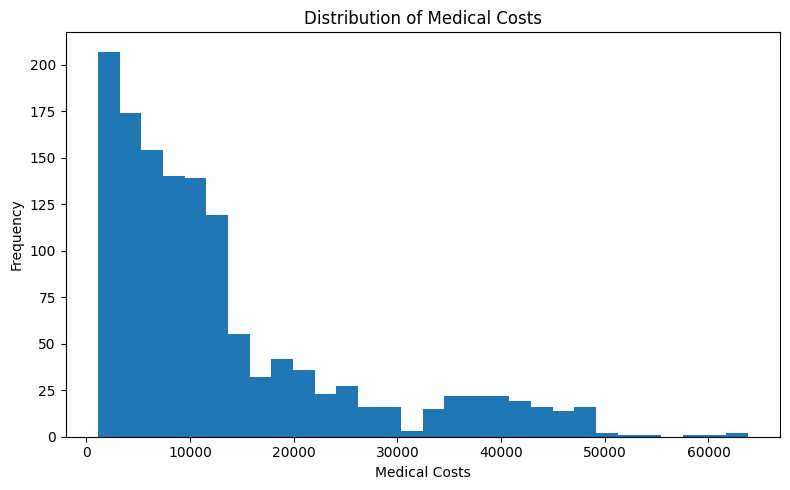

In [60]:
plt.figure(figsize=(8,5))
plt.hist(df["charges"], bins=30)
plt.title("Distribution of Medical Costs")
plt.xlabel("Medical Costs")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Insight:**
The distribution of medical costs is right-skewed, indicating that most individuals have relatively low expenses, while a smaller group incurs significantly higher costs.

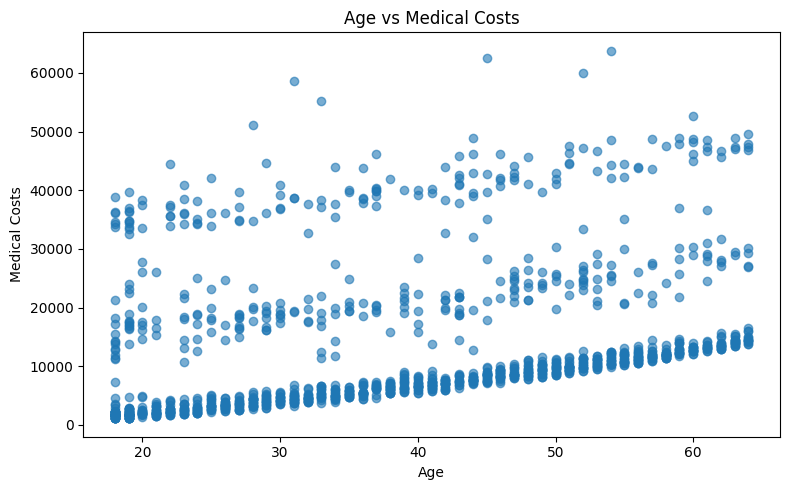

In [61]:
plt.figure(figsize=(8,5))
plt.scatter(df["age"], df["charges"], alpha=0.6)
plt.title("Age vs Medical Costs")
plt.xlabel("Age")
plt.ylabel("Medical Costs")
plt.tight_layout()
plt.show()

**Insight:**
There is a clear positive relationship between age and medical costs, suggesting that healthcare expenses tend to increase as individuals get older.

---

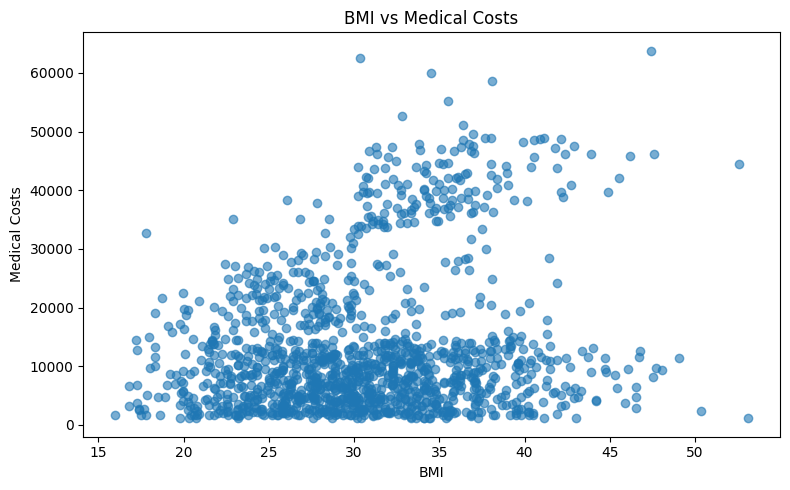

In [62]:
plt.figure(figsize=(8,5))
plt.scatter(df["bmi"], df["charges"], alpha=0.6)
plt.title("BMI vs Medical Costs")
plt.xlabel("BMI")
plt.ylabel("Medical Costs")
plt.tight_layout()
plt.show()

**Insight:**
BMI shows a moderate positive association with medical costs, although with high variability, indicating that additional factors influence healthcare expenses.

---

/tmp/ipykernel_1979/2595956663.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_cost_by_age_group = df.groupby("age_group")["charges"].mean()


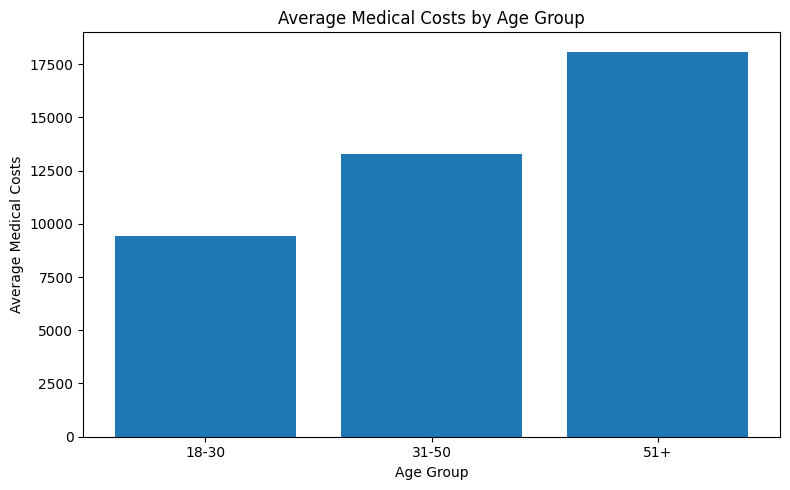

In [63]:
avg_cost_by_age_group = df.groupby("age_group")["charges"].mean()

plt.figure(figsize=(8,5))
plt.bar(avg_cost_by_age_group.index.astype(str), avg_cost_by_age_group.values)
plt.title("Average Medical Costs by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Medical Costs")
plt.tight_layout()
plt.show()

**Insight:**
Average medical costs increase across age groups, reinforcing the strong impact of age on healthcare expenses.

---

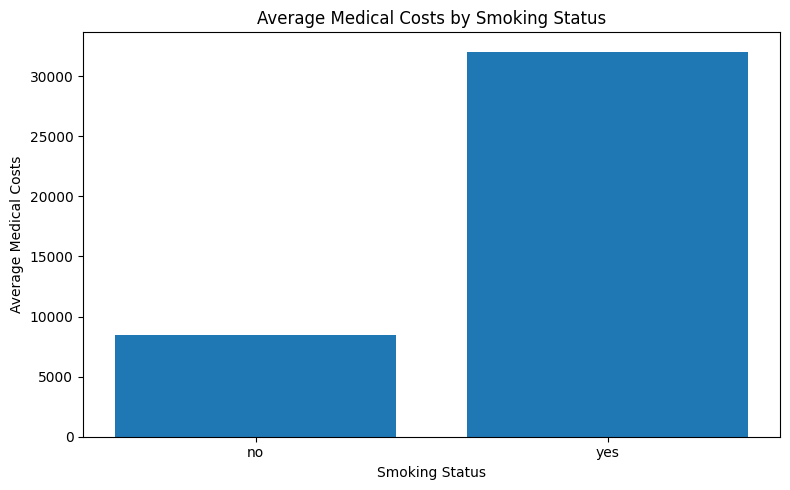

In [67]:
avg_cost_by_smoker = df.groupby("smoker")["charges"].mean()

plt.figure(figsize=(8,5))
plt.bar(avg_cost_by_smoker.index.astype(str), avg_cost_by_smoker.values)
plt.title("Average Medical Costs by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Average Medical Costs")
plt.tight_layout()
plt.show()

**Insight:**
Smokers have significantly higher average medical costs compared to non-smokers, highlighting smoking as a key driver of healthcare expenses.

---

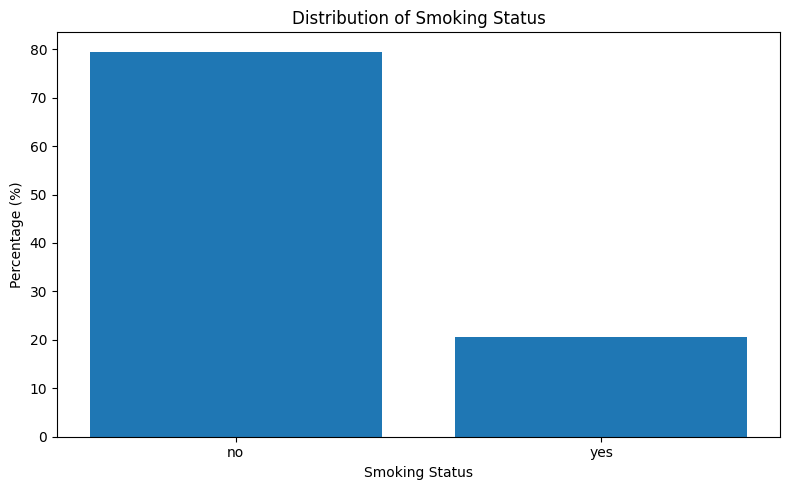

In [70]:
plt.figure(figsize=(8,5))
plt.bar(base_pct["smoker"], base_pct["percentage"])
plt.title("Distribution of Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Percentage (%)")
plt.tight_layout()
plt.show()

**Insight:**
Non-smokers represent the majority of the dataset (79.51%), while smokers account for a significantly smaller portion (20.49%) of the population.

---

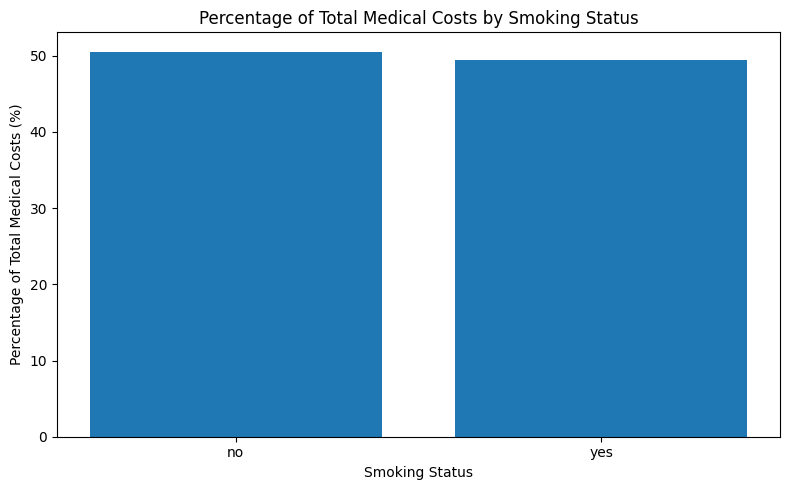

In [65]:
plt.figure(figsize=(8,5))
plt.bar(charges_pct["smoker"], charges_pct["percent_charges"])
plt.title("Percentage of Total Medical Costs by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Percentage of Total Medical Costs (%)")
plt.tight_layout()
plt.show()

**Insight:**
Although smokers represent a smaller portion of the dataset, they account for a disproportionately large share of total medical costs.

---

<Figure size 800x500 with 0 Axes>

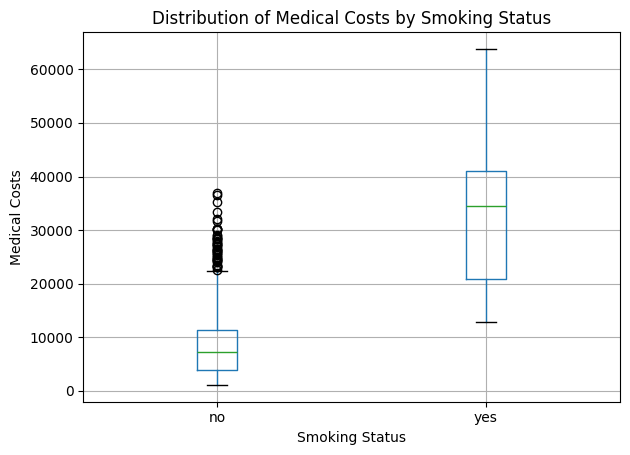

In [66]:
plt.figure(figsize=(8,5))
df.boxplot(column="charges", by="smoker")
plt.title("Distribution of Medical Costs by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoking Status")
plt.ylabel("Medical Costs")
plt.tight_layout()
plt.show()

**Insight:**
Smokers not only have higher medical costs but also greater variability, indicating a wider range of expenses within this group.

---

## 10. Key Insights

- Smokers represent a **minor share of the dataset (20.49%)**, but account for **almost half of total medical costs (49.46%)**.
- Smokers have approximately **4x higher medical costs** compared to non-smokers.
- Medical costs **increase with age**, showing a clear positive relationship.
- The **difference in average costs between men and women is small**.
- Higher BMI is associated with **higher medical costs**, although with high variability.
- Smoking is the **most impactful factor driving healthcare expenses**.

## 11. Conclusion


The analysis indicates that **smoking is the main factor associated with higher medical costs**, with a significantly stronger impact than the other variables. **Age** also shows a positive relationship with costs, while **BMI** presents a more moderate association with high variability. Overall, the results reinforce that medical costs are influenced by multiple factors, with smoking standing out as the most relevant.

## 12. Exporting the Cleaned Dataset

The cleaned dataset was exported to support future analysis in SQL and Power BI.

In [ ]:
df.to_csv("insurance_cleaned.csv", index=False)